## Imports

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats


## Part 1

### Create the LCG random number generator

In [2]:
class LCG:
    xi = 0
    a = 0
    c = 0
    M = 0
    
    
    def __init__(self,a = 1664525, c = 1013904223,  M = 2**32, seed = 42):
        self.a = a
        self.c = c
        self.M = M
        self.xi = seed

    def Generate_single_number(self):
        res = (self.a * self.xi + self.c) % self.M
        self.xi = res

        return res/self.M
    
    def rnd(self, length = 1):
        result = []
        for i in range(length):
            result.append(self.Generate_single_number())


        return result


In [3]:
rng = LCG()



### Generating the data

In [4]:
data = rng.rnd(10000)

## Plotting the data

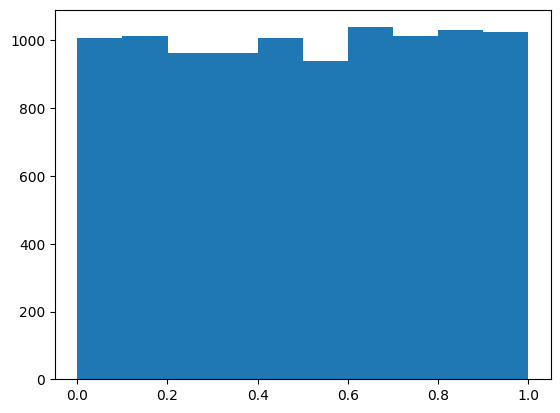

In [5]:
plt.hist(data,10)
plt.show()

## Tests

### Helper functions

In [6]:
def norm_right_tailed_p(z):
# right-tailed test
    p = 1 - stats.norm.cdf(z)
    return p
def norm_left_tailed_p(z):
# left-tailed test
    p = stats.norm.cdf(z)
    return p
def norm_two_sided_p(z):
    #two sided test
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return p

### Chi test

In [7]:
def chi(samples, bucket_amount = 10):
    sorted_samples = samples.copy()
    sorted_samples.sort()
    length = len(samples)

    bucket_size = 1 / bucket_amount
    counts = [0 for i in range(bucket_amount)]

    indx = 0

    print(f'bucket size =  {bucket_size}')
    print(f'bucket amount = {bucket_amount}')

    for i in range(bucket_amount):
        lower = bucket_size * i
        upper = bucket_size * (i + 1)

        count = 0 # count moved into the for loop, so its no longer cumulative

        while indx < length and sorted_samples[indx] < upper:
            count += 1
            indx += 1

        counts[i] = count

    expected_count = length / bucket_amount

    print(f'observed = {counts}')
    print(f'expected count per bucket = {expected_count}')

    T = 0
    for observed in counts:
        T += ((observed - expected_count) ** 2) / expected_count

    p = stats.chi2.sf(T, df = bucket_amount - 1) # use sf instead to find the probability of finding a p-value atleast the value as the observed

    return T, p

### Kolmogorov-Smirnov test

In [8]:
def KS(samples):
    sorted_samples = samples.copy()
    sorted_samples.sort()

    length = len(samples)

    Dn = 0

    for i in range(length):
        x = sorted_samples[i]

        # Empirical CDF just after the jump at x
        F_emp_upper = (i + 1) / length

        # Empirical CDF just before the jump at x
        F_emp_lower = i / length

        # For Uniform(0, 1), the theoretical CDF is F(x) = x
        F_theory = x

        # Check both sides of the empirical CDF jump
        D_plus = abs(F_emp_upper - F_theory)
        D_minus = abs(F_emp_lower - F_theory)

        # Keep the largest difference seen so far
        Dn = max(Dn, D_plus, D_minus)

    adjusted = (np.sqrt(length) + 0.12 + 0.11 / np.sqrt(length)) * Dn

    p = stats.kstest(samples, 'uniform').pvalue

    print(f"Dn = {Dn}")
    print(f"adjusted KS statistic = {adjusted}")
    print(f"p-value = {p}")

    return Dn, adjusted, p

### Correlation test

In [9]:
def correlation_test(samples, h = 1):
    n = len(samples)

    if h >= n:
        raise ValueError("h must be smaller than the number of samples")

    total = 0

    for i in range(n - h):
        total += samples[i] * samples[i + h]

    C_h = total / (n - h)

    expected = 1 / 4
    variance = 7 / (144 * n)
    std = np.sqrt(variance)

    z = (C_h - expected) / std
    p = norm_two_sided_p(z)

    print(f"h = {h}")
    print(f"C_h = {C_h}")
    print(f"z = {z}")
    print(f"p-value = {p}")

    return C_h, z, p

##  Run-tests

### Wald Wolfowitz

In [10]:
def Wald_Wolfowitz(samples):
    #find the median

    sorted_samples = samples.copy() # only used for finding the median
    sorted_samples.sort()
    if len(sorted_samples) % 2 == 1: # samples er ulige
        median = sorted_samples[int((len(sorted_samples)/2))]
    else:
        median = (sorted_samples[int(len(sorted_samples)/2)] + sorted_samples[(int(len(sorted_samples)/2))-1])/2
    print(f"median found to be: {median}")



    L = 0 # number of runs in the lower part
    H = 0 # number of runs in the upper part
    n1 = 0 #number of elements below  the median
    n2 = 0 #number of elements above the median

    #used to check if we are currently in a higher or lower run already
    in_lower_run = False 
    in_higher_run = False
    for sample in samples:
        if sample < median : # lower half of the median
            n1 += 1
            if not in_lower_run:
                in_lower_run = True
                in_higher_run = False
                L += 1

        elif sample > median:
            n2 += 1
            if not in_higher_run:
                in_lower_run = False
                in_higher_run = True
                H += 1
    

    T = H + L

    print(f"n1: {n1}\nn2:{n2}\ntotal number of runs:{T}")
    mu  = 2 * (n1*n2) /  (n1 + n2) + 1
    var = 2 * (n1 * n2 * (2 * n1 * n2 - n1 - n2)) / ( (n1 + n2 )**2 * (n1 + n2 -1) )
    std = np.sqrt(var)

    z = (T - mu) / std # tells me how many stds from the expected result we are.
    #(x - mean) / standard_deviation)
    p = norm_two_sided_p(z)
    
    
    #RIGHT NOW ALL VALUES EQUAL TO MEDIAN ARE IGNORED
    print(f'z value found to be {z}')
    print(f'p value found to be {p}') 

    return T,z,p

            
        


### Up/Down - Knuth

In [ ]:
#Old and unused version just kept in case its needed
def Knuth_Up_Down(samples, max_runlength = 6):
    n = len(samples)

    if n < 2: # small check to make sure that there is atleast 2 elements in samples
        return [0 for _ in range(max_runlength)]
    
    if samples[0] < samples[1]: # checks if the first run is an up-run
        in_up_run   = True #first run is set to an up run
        in_down_run = False
    else:
        in_up_run   = False
        in_down_run = True #first run in a down-run

    
    current_run_length = 1 #starts at 1 because we skip the first number, but its still a part of the run-of course :)
    first_run = True # is this the first run?
    R = [0 for i in range(max_runlength)] #vector that records how many runs of different lengths

    for sample in samples:
        if first_run: #if its the first run-skip 
            first_run = False
        else:
            if sample > prev: # we are in an up-run

                if in_down_run: # we were in a down-run before, meaning the down-run has ended
                    R[min(current_run_length - 1 , max_runlength - 1)] += 1 #-1 since indexing starts at 0 but lengths start at 1 and "min" so we dont go above max_run length
                    current_run_length = 2 #reset run length
                    in_down_run = False
                    in_up_run = True
                else:
                    current_run_length += 1
            
            else: #we are in a down-run
                if in_up_run: # we were in an up-run before, which has ended now
                    R[min(current_run_length - 1 , max_runlength - 1)] += 1 #-1 since indexing starts at 0 but lengths start at 1 and "min" so we dont go above max_run length
                    current_run_length = 2 #reset run length
                    in_down_run = True
                    in_up_run = False
                else:
                    current_run_length += 1
            # count final run
        prev = sample

    R[min(current_run_length - 1 , max_runlength - 1)] += 1 #count the final run

    B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

    A = np.array([
        [4529.4, 9044.9, 13568, 18091, 22615, 27892],
        [9044.9, 18097, 27139, 36187, 45234, 55789],
        [13568, 27139, 40721, 54281, 67852, 83685],
        [18091, 36187, 54281, 72414, 90470, 111580],
        [22615, 45234, 67852, 90470, 113262, 139476],
        [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    R = np.array(R)

    diff = R - n * B

    Z = (1 / (n - 6)) * diff.T @ A @ diff
    return stats.chi2.cdf(Z,6)


def Knuth_Up(samples, max_runlength = 6):
    n = len(samples)

    if n < 2:
        return [0 for _ in range(max_runlength)]

    R = [0 for i in range(max_runlength)]

    current_run_length = 1

    for i in range(1, n):
        if samples[i] > samples[i - 1]:
            # still in an up-run
            current_run_length += 1
        else:
            # up-run ended, so count it
            R[min(current_run_length - 1, max_runlength - 1)] += 1
            current_run_length = 1

    # count final up-run
    R[min(current_run_length - 1, max_runlength - 1)] += 1

    B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

    A = np.array([
        [4529.4, 9044.9, 13568, 18091, 22615, 27892],
        [9044.9, 18097, 27139, 36187, 45234, 55789],
        [13568, 27139, 40721, 54281, 67852, 83685],
        [18091, 36187, 54281, 72414, 90470, 111580],
        [22615, 45234, 67852, 90470, 113262, 139476],
        [27892, 55789, 83685, 111580, 139476, 172860]
    ])

    R = np.array(R)

    diff = R - n * B

    Z = (1 / (n - 6)) * diff.T @ A @ diff

    p = stats.chi2.sf(Z, df = 6)

    print(f"R = {R}")
    print(f"Z = {Z}")
    print(f"p-value = {p}")

    return R, Z, p

### Running the tests

In [12]:
print("\nKS")
print(KS(data))

print("\nChi-square")
print(chi(data))

print("\nWald-Wolfowitz")
print(Wald_Wolfowitz(data))

print("\nKnuth up-run test")
print(Knuth_Up(data))

print("\nCorrelation test")
print(correlation_test(data, h = 1))


KS
Dn = 0.012506133062019975
adjusted KS statistic = 1.2521277989158082
p-value = 0.08686683982703247
(0.012506133062019975, np.float64(1.2521277989158082), np.float64(0.08686683982703247))

Chi-square
bucket size =  0.1
bucket amount = 10
observed = [1005, 1011, 964, 963, 1009, 940, 1039, 1013, 1030, 1026]
expected count per bucket = 1000.0
(9.758000000000001, np.float64(0.37042949764030597))

Wald-Wolfowitz
median found to be: 0.5047790677053854
n1: 5000
n2:5000
total number of runs:4976
z value found to be -0.5000250043757813
p value found to be 0.617057471214574
(4976, np.float64(-0.5000250043757813), np.float64(0.617057471214574))

Knuth up-run test
R = [1766 2133  873  243   61   12]
Z = 14.09530548765138
p-value = 0.028589479431582184
(array([1766, 2133,  873,  243,   61,   12]), np.float64(14.09530548765138), np.float64(0.028589479431582184))

Correlation test
h = 1
C_h = 0.25403818459436606
z = 1.831548374548256
p-value = 0.067018734292847
(0.25403818459436606, np.float64(1.8

### LCG parameter experimentation

In [13]:
rng_1 = LCG(a = 4,c=10,M = 120)
data_1 = rng_1.rnd(10000)
print("\nKS_1")
print(KS(data_1))

print("\nChi-square_1")
print(chi(data_1))

print("\nWald-Wolfowitz_1")
print(Wald_Wolfowitz(data_1))

print("\nKnuth up-run test_1")
print(Knuth_Up(data_1))

print("\nCorrelation test_1")
print(correlation_test(data_1, h = 1))


KS_1
Dn = 0.18339999999999998
adjusted KS statistic = 18.362209739999997
p-value = 7.505341121061189e-295
(0.18339999999999998, np.float64(18.362209739999997), np.float64(7.505341121061189e-295))

Chi-square_1
bucket size =  0.1
bucket amount = 10
observed = [1667, 1667, 0, 1666, 1667, 0, 1667, 0, 1666, 0]
expected count per bucket = 1000.0
(6666.668, np.float64(0.0))

Wald-Wolfowitz_1
median found to be: 0.41666666666666663
n1: 5000
n2:5000
total number of runs:6667
z value found to be 33.32166629160207
p value found to be 0.0
(6667, np.float64(33.32166629160207), np.float64(0.0))

Knuth up-run test_1
R = [   1 1666    1 1666    0    0]
Z = 10529.090745925521
p-value = 0.0
(array([   1, 1666,    1, 1666,    0,    0]), np.float64(10529.090745925521), np.float64(0.0))

Correlation test_1
h = 1
C_h = 0.1876401806847273
z = -28.283755493337214
p-value = 0.0
(0.1876401806847273, np.float64(-28.283755493337214), np.float64(0.0))


## Part 2

In [14]:
system_data = np.random.uniform(0,1,10000)

print("\nKS_system")
print(KS(system_data))

print("\nChi-square_system")
print(chi(system_data))

print("\nWald-Wolfowitz_system")
print(Wald_Wolfowitz(system_data))

print("\nKnuth up-run test_system")
print(Knuth_Up(system_data))

print("\nCorrelation test_system")
print(correlation_test(system_data, h = 1))



KS_system
Dn = 0.008850193617973845
adjusted KS statistic = 0.8860911202445211
p-value = 0.4113799292083675
(np.float64(0.008850193617973845), np.float64(0.8860911202445211), np.float64(0.4113799292083675))

Chi-square_system
bucket size =  0.1
bucket amount = 10
observed = [1004, 1007, 1044, 978, 922, 1024, 1004, 1017, 986, 1014]
expected count per bucket = 1000.0
(9.841999999999999, np.float64(0.3634271074195347))

Wald-Wolfowitz_system
median found to be: 0.505702414538078
n1: 5000
n2:5000
total number of runs:5040
z value found to be 0.7800390068262189
p value found to be 0.43536791571044375
(5040, np.float64(0.7800390068262189), np.float64(0.43536791571044375))

Knuth up-run test_system
R = [1648 2101  917  260   58   11]
Z = 1.151023998122927
p-value = 0.9792346595262932
(array([1648, 2101,  917,  260,   58,   11]), np.float64(1.151023998122927), np.float64(0.9792346595262932))

Correlation test_system
h = 1
C_h = 0.24989215665482456
z = -0.04891314375214491
p-value = 0.96098851

### Part 3

one sample is not enough and we probably need to do multiple runs, since we are using p = 0.05 it means that 5% of the time we will hit a run which we will reject.

### multiple samples

In [16]:
def repeated_tests(repetitions=100, sample_size=10000, alpha=0.05):
    rejected = {
        "KS": 0,
        "Chi-square": 0,
        "Wald-Wolfowitz": 0,
        "Knuth": 0,
        "Correlation": 0
    }

    for seed in range(repetitions):
        rng = LCG(seed=seed)
        samples = rng.rnd(sample_size)

        ks_p = KS(samples)[-1]
        chi_p = chi(samples)[-1]
        ww_p = Wald_Wolfowitz(samples)[-1]
        knuth_p = Knuth_Up(samples)[-1]
        corr_p = correlation_test(samples, h=1)[-1]

        if ks_p < alpha:
            rejected["KS"] += 1
        if chi_p < alpha:
            rejected["Chi-square"] += 1
        if ww_p < alpha:
            rejected["Wald-Wolfowitz"] += 1
        if knuth_p < alpha:
            rejected["Knuth"] += 1
        if corr_p < alpha:
            rejected["Correlation"] += 1

    print(f"Repeated each test {repetitions} times")
    print(f"Significance level alpha = {alpha}")
    print()

    for test_name in rejected:
        rejection_rate = rejected[test_name] / repetitions
        print(f"{test_name}: rejected {rejected[test_name]} times, rejection rate = {rejection_rate}")

In [18]:
repeated_tests()

Dn = 0.006395835665613414
adjusted KS statistic = 0.6403581022604472
p-value = 0.8054433275575248
bucket size =  0.1
bucket amount = 10
observed = [995, 1020, 1027, 974, 979, 978, 1028, 968, 1003, 1028]
expected count per bucket = 1000.0
median found to be: 0.5003357928944752
n1: 5000
n2:5000
total number of runs:4976
z value found to be -0.5000250043757813
p value found to be 0.617057471214574
R = [1712 2093  946  242   47   10]
Z = 6.4803076000295174
p-value = 0.3715867530837075
h = 1
C_h = 0.25114515082051725
z = 0.5193915916714634
p-value = 0.6034876936483098
Dn = 0.007874301645532267
adjusted KS statistic = 0.7883837424825006
p-value = 0.5619904385574752
bucket size =  0.1
bucket amount = 10
observed = [1012, 1017, 1029, 1001, 970, 973, 1003, 1024, 994, 977]
expected count per bucket = 1000.0
median found to be: 0.4975409845355898
n1: 5000
n2:5000
total number of runs:5022
z value found to be 0.4200210036756563
p value found to be 0.6744701100467674
R = [1673 2118  899  271   47  